In [20]:
import mediapipe as mp
import numpy as np
import cv2

print("mediapipe:", mp.__version__)
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)

mediapipe: 0.10.32
numpy: 2.4.1
opencv: 4.11.0


In [22]:
import os
import cv2
import csv
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

VIDEO_PATH = "datasets/archive/videos/00336.mp4"
MODEL_PATH = "models/hand_landmarker.task"
OUT_CSV = "asl_hand_landmarks_per_frame.csv"
OUT_NPZ = "asl_hand_landmarks_per_frame.npz"

assert os.path.exists(VIDEO_PATH), f"Video not found: {VIDEO_PATH}"
assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"

BaseOptions = python.BaseOptions
HandLandmarker = vision.HandLandmarker
HandLandmarkerOptions = vision.HandLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

def to63(lms21):
    arr = np.array([[lm.x, lm.y, lm.z] for lm in lms21], dtype=np.float32)  # (21,3)
    return arr.reshape(-1)  # (63,)

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

nan63 = np.full((63,), np.nan, dtype=np.float32)

frames = []
timestamps = []
left = []
right = []
left_present = []
right_present = []
left_score = []
right_score = []

with HandLandmarker.create_from_options(options) as landmarker:
    frame_idx = 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        timestamp_ms = int((frame_idx / fps) * 1000)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        # Default: missing
        l_vec, r_vec = nan63.copy(), nan63.copy()
        l_ok, r_ok = 0, 0
        l_sc, r_sc = 0.0, 0.0

        if result.hand_landmarks:
            # Assign each detected hand into left/right buckets
            for i, hand_lms in enumerate(result.hand_landmarks):
                label = result.handedness[i][0].category_name  # "Left" or "Right"
                score = float(result.handedness[i][0].score)
                vec = to63(hand_lms)

                if label == "Left":
                    l_vec, l_ok, l_sc = vec, 1, score
                elif label == "Right":
                    r_vec, r_ok, r_sc = vec, 1, score

        frames.append(frame_idx)
        timestamps.append(timestamp_ms)
        left.append(l_vec)
        right.append(r_vec)
        left_present.append(l_ok)
        right_present.append(r_ok)
        left_score.append(l_sc)
        right_score.append(r_sc)

        frame_idx += 1

cap.release()

frames = np.array(frames, dtype=np.int32)
timestamps = np.array(timestamps, dtype=np.int32)
left = np.stack(left, axis=0)    # (T,63)
right = np.stack(right, axis=0)  # (T,63)
left_present = np.array(left_present, dtype=np.int8)
right_present = np.array(right_present, dtype=np.int8)
left_score = np.array(left_score, dtype=np.float32)
right_score = np.array(right_score, dtype=np.float32)

# Save NPZ
np.savez_compressed(
    OUT_NPZ,
    frames=frames,
    timestamps_ms=timestamps,
    left=left,
    right=right,
    left_present=left_present,
    right_present=right_present,
    left_score=left_score,
    right_score=right_score,
    fps=np.array([fps], dtype=np.float32),
)

# Save CSV (optional)
header = (["frame", "timestamp_ms",
           "left_present", "right_present",
           "left_score", "right_score"] +
          [f"left_lm{i}_{a}" for i in range(21) for a in ("x","y","z")] +
          [f"right_lm{i}_{a}" for i in range(21) for a in ("x","y","z")])

with open(OUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(header)
    for t in range(len(frames)):
        w.writerow([
            int(frames[t]), int(timestamps[t]),
            int(left_present[t]), int(right_present[t]),
            float(left_score[t]), float(right_score[t]),
            *left[t].tolist(), *right[t].tolist()
        ])

print(f"Done.\nVideo frames: {len(frames)} / {frame_count}, fps={fps:.2f}")
print(f"Saved:\n- {OUT_NPZ}\n- {OUT_CSV}")
print("Shapes:", {
    "left": left.shape,
    "right": right.shape,
    "left_present": left_present.shape,
    "right_present": right_present.shape
})

I0000 00:00:1769844244.616292 3570374 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Pro
W0000 00:00:1769844244.624913 3570380 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769844244.639395 3570380 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Done.
Video frames: 65 / 65, fps=30.00
Saved:
- asl_hand_landmarks_per_frame.npz
- asl_hand_landmarks_per_frame.csv
Shapes: {'left': (65, 63), 'right': (65, 63), 'left_present': (65,), 'right_present': (65,)}


# visual verification

In [6]:
import pandas as pd

NPZ_PATH = "asl_hand_landmarks_per_frame.npz"
CSV_PATH = "asl_hand_landmarks_per_frame.csv"

d = np.load(NPZ_PATH, allow_pickle=True)
print("NPZ keys:", d.files)
print("NPZ frames:", len(d["frames"]))
print("Left shape:", d["left"].shape, "Right shape:", d["right"].shape)

df = pd.read_csv(CSV_PATH)
print("CSV rows:", len(df))
print("First/last frame index:", df["frame"].iloc[0], df["frame"].iloc[-1])

# How many frames have no left/right detected?
print("Missing left:", int((df["left_present"] == 0).sum()))
print("Missing right:", int((df["right_present"] == 0).sum()))

# Check if any frame indices are missing (gaps)
frames = df["frame"].to_numpy()
gaps = frames[np.where(np.diff(frames) != 1)[0]]
print("Gap frames (should be empty):", gaps[:10])

NPZ keys: ['frames', 'timestamps_ms', 'left', 'right', 'left_present', 'right_present', 'left_score', 'right_score', 'fps']
NPZ frames: 105
Left shape: (105, 63) Right shape: (105, 63)
CSV rows: 105
First/last frame index: 0 104
Missing left: 33
Missing right: 33
Gap frames (should be empty): []


I0000 00:00:1769419605.462552  444642 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Pro
W0000 00:00:1769419605.472156  444647 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769419605.482057  444654 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


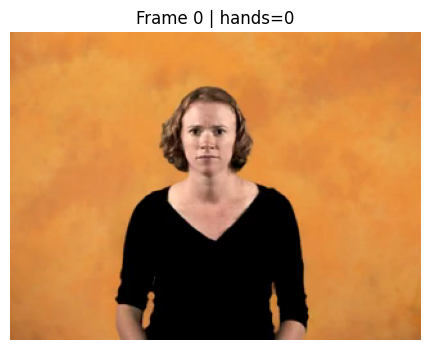

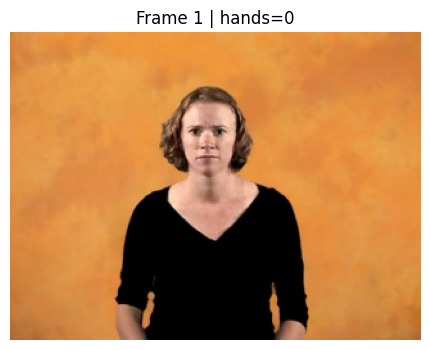

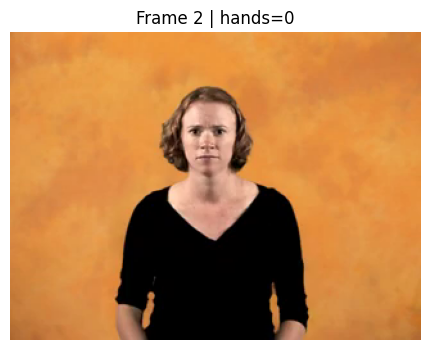

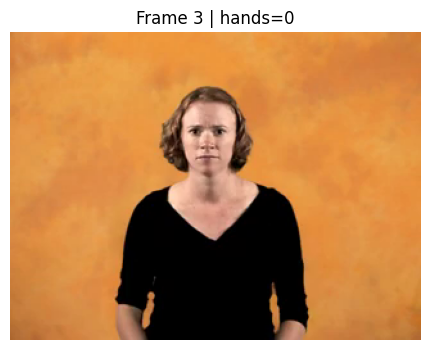

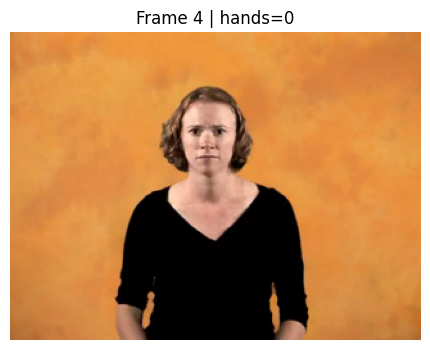

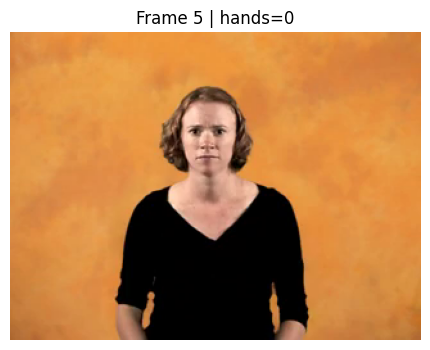

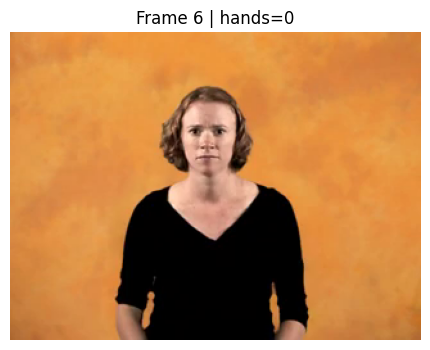

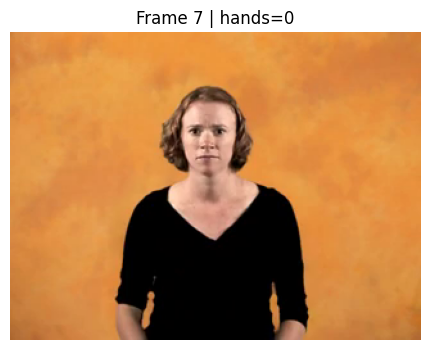

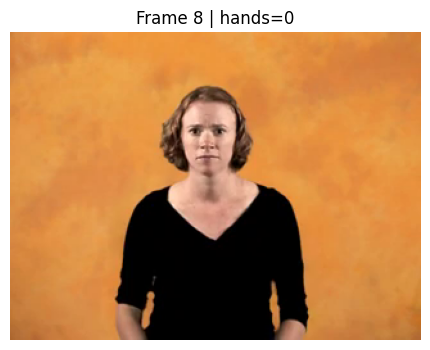

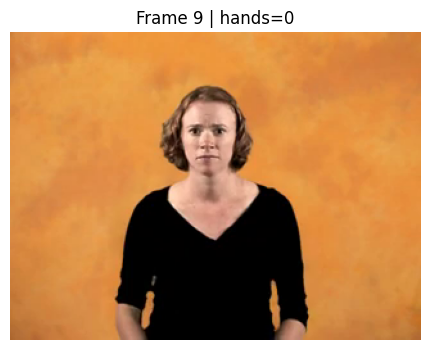

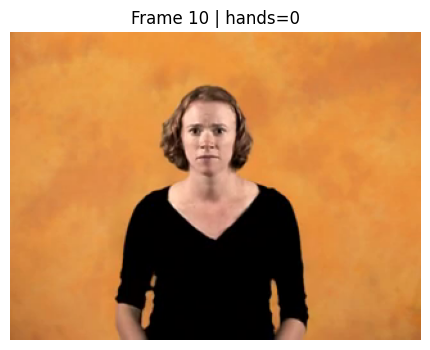

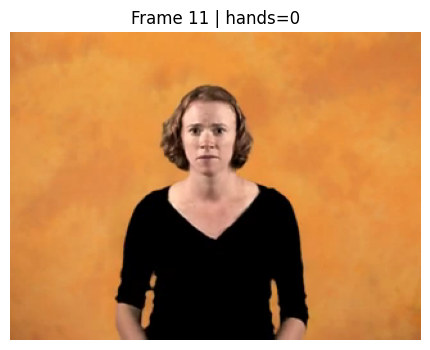

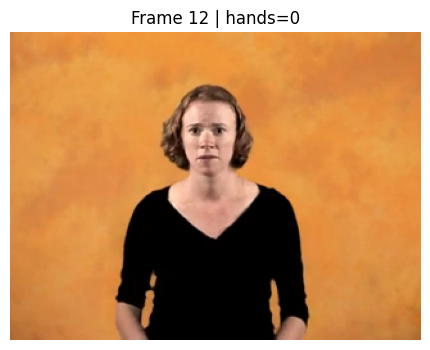

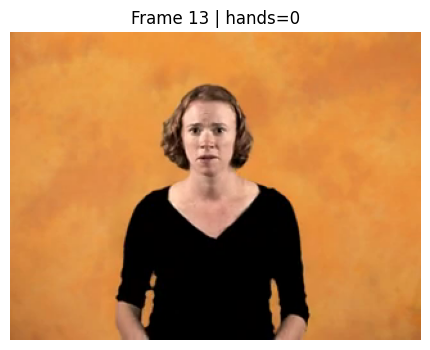

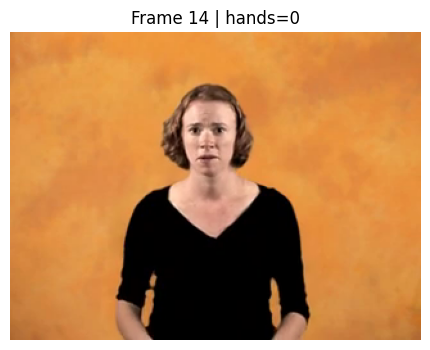

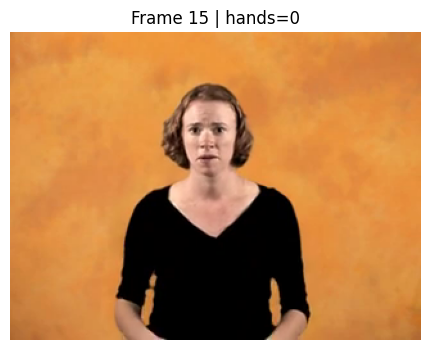

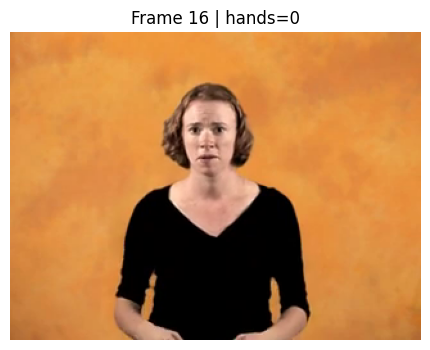

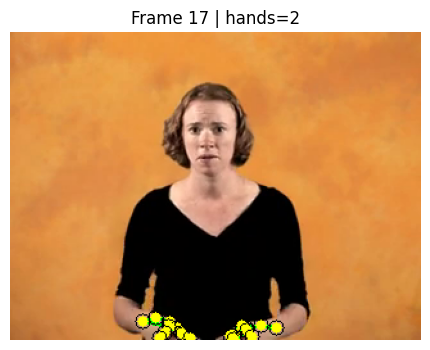

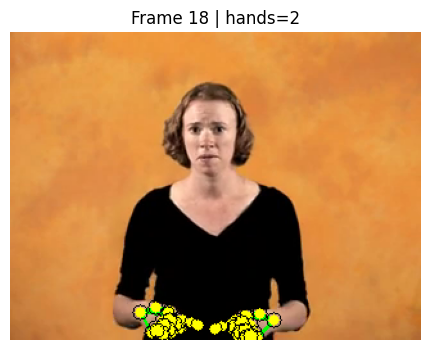

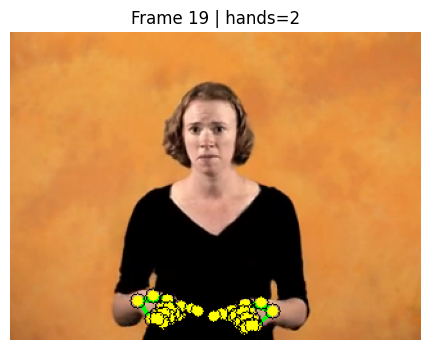

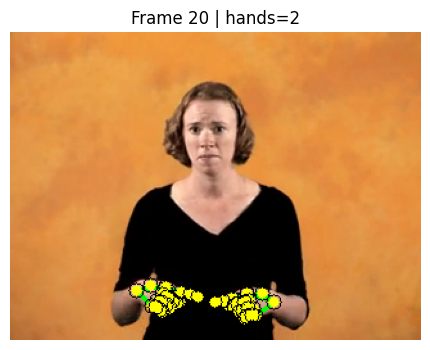

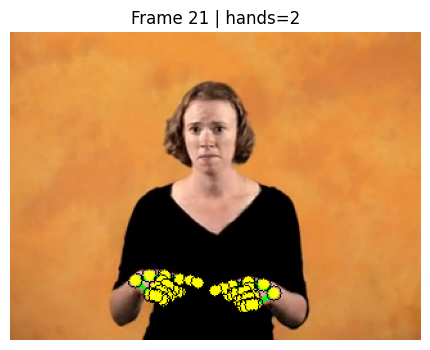

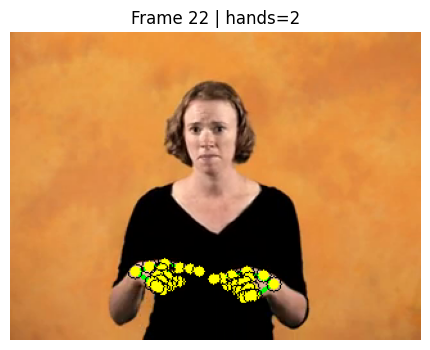

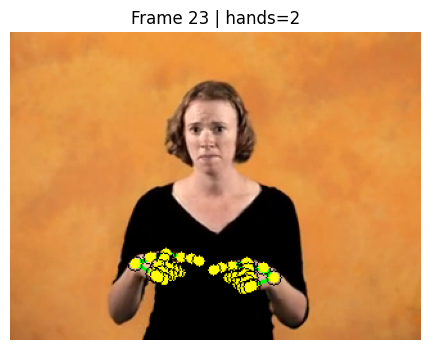

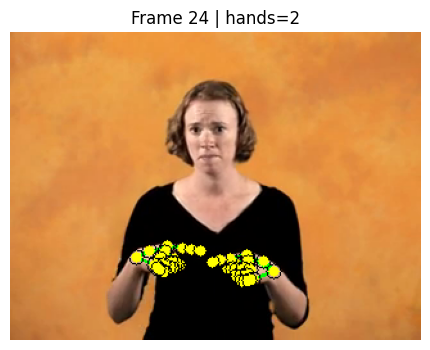

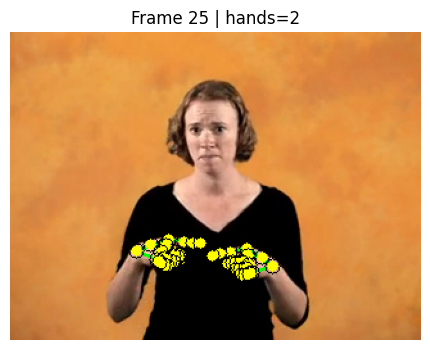

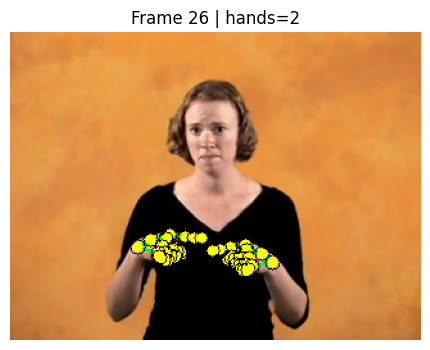

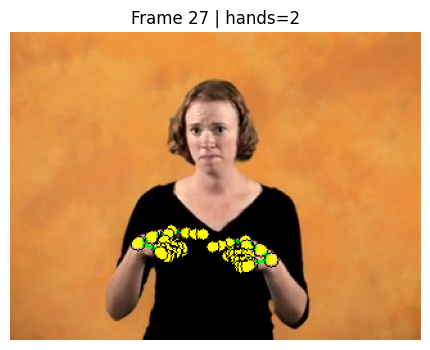

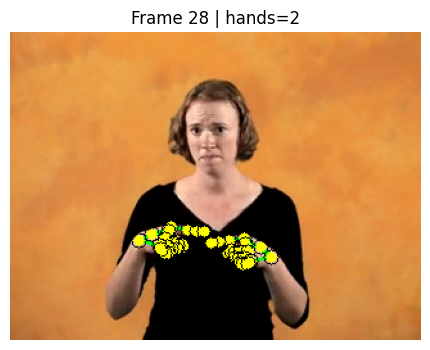

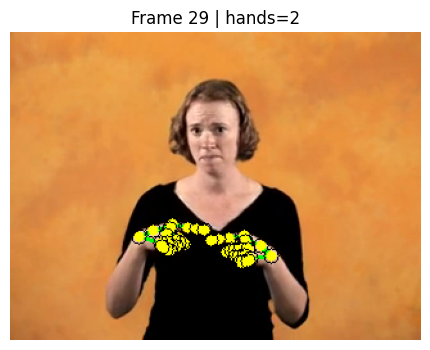

In [14]:
from matplotlib import pyplot as plt

# import cv2
#import numpy as np
#import mediapipe as mp
#from matplotlib import pyplot as plt
#from mediapipe.tasks import python
#from mediapipe.tasks.python import vision

VIDEO_PATH = "datasets/archive/videos/00414.mp4"
MODEL_PATH = "models/hand_landmarker.task"
START_FRAME = 0
NUM_FRAMES = 30

BaseOptions = python.BaseOptions
HandLandmarkerOptions = vision.HandLandmarkerOptions
HandLandmarker = vision.HandLandmarker
VisionRunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
)

# MediaPipe Hands landmark connection pairs (indices 0..20)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index
    (5, 9), (9, 10), (10, 11), (11, 12),   # Middle
    (9, 13), (13, 14), (14, 15), (15, 16), # Ring
    (13, 17), (17, 18), (18, 19), (19, 20),# Pinky
    (0, 17)                                 # Palm base
]

def _to_px(lm, w, h):
    return int(lm.x * w), int(lm.y * h)

def draw_hand_landmarks_bgr(img_bgr, hand_lms, draw_connections=True):
    """Draw 21 hand landmarks (and optional connections) on a BGR image using OpenCV."""
    h, w = img_bgr.shape[:2]

    # Draw connections first (behind points)
    if draw_connections:
        for a, b in HAND_CONNECTIONS:
            x1, y1 = _to_px(hand_lms[a], w, h)
            x2, y2 = _to_px(hand_lms[b], w, h)
            if (0 <= x1 < w and 0 <= y1 < h and 0 <= x2 < w and 0 <= y2 < h):
                cv2.line(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Draw landmark points
    for lm in hand_lms:
        cx, cy = _to_px(lm, w, h)
        if 0 <= cx < w and 0 <= cy < h:
            cv2.circle(img_bgr, (cx, cy), 4, (0, 255, 255), -1)  # filled
            cv2.circle(img_bgr, (cx, cy), 6, (0, 0, 0), 1)       # outline

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
cap.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME)

with HandLandmarker.create_from_options(options) as landmarker:
    for k in range(NUM_FRAMES):
        frame_idx = START_FRAME + k
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        timestamp_ms = int((frame_idx / fps) * 1000)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        annotated = frame_bgr.copy()
        hands_count = 0

        if result.hand_landmarks:
            hands_count = len(result.hand_landmarks)
            for hand_lms in result.hand_landmarks:
                draw_hand_landmarks_bgr(annotated, hand_lms, draw_connections=True)

        plt.figure(figsize=(7, 4))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"Frame {frame_idx} | hands={hands_count}")
        plt.axis("off")
        plt.show()

cap.release()

In [8]:
import cv2
import csv
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

VIDEO_PATH = "datasets/archive/videos/00414.mp4"
MODEL_PATH = "hand_landmarker.task"   # download from MediaPipe Hand Landmarker models page
OUT_CSV = "hand_landmarks.csv"

BaseOptions = python.BaseOptions
HandLandmarker = vision.HandLandmarker
HandLandmarkerOptions = vision.HandLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,                 # ASL often uses two hands
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

def flatten_landmarks(landmarks_21):
    # landmarks_21: list of 21 NormalizedLandmark
    flat = []
    for lm in landmarks_21:
        flat.extend([lm.x, lm.y, lm.z])
    return flat  # length 63

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

with HandLandmarker.create_from_options(options) as landmarker, \
     open(OUT_CSV, "w", newline="") as f:

    writer = csv.writer(f)

    # header: frame_index, timestamp_ms, hand_label, handedness_score, 63 values
    header = ["frame", "timestamp_ms", "handedness", "handedness_score"] + \
             [f"lm{i}_{axis}" for i in range(21) for axis in ("x", "y", "z")]
    writer.writerow(header)

    frame_idx = 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        # IMPORTANT: timestamps must be monotonic increasing in VIDEO mode.  [oai_citation:4‡Google AI for Developers](https://ai.google.dev/edge/api/mediapipe/python/mp/tasks/vision/HandLandmarker?utm_source=chatgpt.com)
        timestamp_ms = int((frame_idx / fps) * 1000)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        # result.hand_landmarks is a list (one entry per detected hand)  [oai_citation:5‡Google AI for Developers](https://ai.google.dev/edge/api/mediapipe/python/mp/tasks/vision/HandLandmarker?utm_source=chatgpt.com)
        for hand_i, hand_landmarks in enumerate(result.hand_landmarks):
            handed = result.handedness[hand_i][0].category_name   # "Left"/"Right"
            score = result.handedness[hand_i][0].score
            row = [frame_idx, timestamp_ms, handed, score] + flatten_landmarks(hand_landmarks)
            writer.writerow(row)

        frame_idx += 1

cap.release()
print(f"Saved: {OUT_CSV}")

OpenCV: Couldn't read video stream from file "asl_video.mp4"


FileNotFoundError: Unable to open file at hand_landmarker.task

In [18]:
print("this is the end")

this is the end
